In [1]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

#### Nesse notebook, geraremos um modelo simplificado, sem GridSearch, sem StratifiedKFold, apenas pra gerar nossa primeira pravisão e submissão, e avaliar o progresso do nosso modelo ao longo do percurso.

In [7]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X=X.copy()
        X['Total_vs_monthly'] = X['TotalCharges']/X['MonthlyCharges']
        
        return X

In [8]:
df.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [9]:
df = joblib.load('df_att.pkl')

index = df['id']

target = 'Churn'

X = df.drop([target, 'id'], axis=1)
y = df[target]

In [10]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45


In [11]:
def extract_xy(df):
    target = 'Churn'
    X = df.drop([target, 'id'], axis=1)
    y = df[target]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

    return X_train, X_val, y_train, y_val



In [12]:
X_train, X_val, y_train, y_val = extract_xy(df)

cat_features = X_train.select_dtypes(exclude='number').columns.tolist()
num_features = X_train.select_dtypes(include='number').columns.tolist()

In [13]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
220325,Male,1,No,No,23,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,88.85,2193.65
305075,Female,0,Yes,Yes,70,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,Two year,Yes,Credit card (automatic),99.30,6725.50
460412,Female,0,No,No,18,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.75,1340.80
361575,Female,0,No,Yes,9,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,69.15,572.45
121133,Female,0,No,No,3,No,No phone service,DSL,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,29.65,82.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404661,Female,0,Yes,Yes,17,Yes,No,DSL,No,No,No,Yes,No,No,One year,No,Mailed check,50.70,765.15
296515,Female,1,No,No,7,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.85,477.80
97289,Male,0,No,No,36,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.45,3409.60
257525,Female,0,Yes,Yes,51,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),50.30,2633.40


In [14]:
model = CatBoostClassifier(iterations = 108, learning_rate=0.6, depth=6, l2_leaf_reg=1.2, border_count=150, eval_metric='AUC', cat_features=cat_features, verbose=100)

In [15]:
pipe = Pipeline([
    ('fe', FeatureEngineer()),
    ('model', model)
])

In [16]:
pipe.fit(X_train, y_train)


0:	total: 344ms	remaining: 36.8s
100:	total: 18.7s	remaining: 1.3s
107:	total: 20s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fe', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [17]:
pred = pipe.predict(X_val)

score = roc_auc_score(y_val, pred)
score

0.780929725025864

In [20]:
pipe.named_steps['model'].feature_importances_

array([ 0.05988192,  1.62749656,  0.31402311,  1.36507089, 17.09280777,
        0.62298351,  0.91396388,  0.34056497,  1.9224682 ,  0.55131063,
        0.40142142,  0.90796211,  0.18352795,  0.66292056, 14.12112707,
        7.36044792,  5.27551075, 27.45671681,  4.13981583, 14.67997814])

In [21]:
pipe.fit(X, y)

0:	total: 215ms	remaining: 23s
100:	total: 21s	remaining: 1.46s
107:	total: 22.5s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fe', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [23]:
test = joblib.load('test_att.pkl')
index = test['id']
test = test.drop('id', axis=1)

In [24]:


test_fe = pipe.named_steps['fe'].transform(test)

In [25]:
test_predict = model.predict_proba(test_fe)[:,1]
test_predict

array([0.07761353, 0.00159991, 0.11655012, ..., 0.29833493, 0.00173841,
       0.39765962], shape=(254655,))

In [26]:
df_test = pd.DataFrame({'id': index, 'Churn': test_predict})

df_test.head(3)

,id,Churn
0,594194,0.077614
1,594195,0.001600
2,594196,0.116550


In [27]:
df_test.to_csv('1.2_submission.csv', index=False)


In [29]:
predict = pipe.predict(X_val)


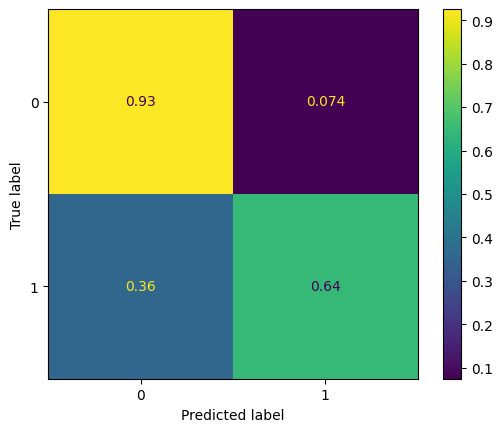

In [30]:
ConfusionMatrixDisplay.from_predictions(y_val, predict, normalize='true')

In [31]:
recall = recall_score(y_val, predict)

In [32]:
recall

0.6440436461809592

In [34]:
df = pipe.named_steps['fe'].fit_transform(df)


In [35]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_vs_monthly
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0,27.518303
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0,54.362590
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0,58.180777
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1,1.014347
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1,1.000000


In [37]:
df.to_pickle('df_att.pkl')
